# 3D supercell tight-binding: polycell crystal quantum states

This notebook builds a 3D polycell crystal supercell, constructs a real-space tight-binding Hamiltonian, and solves the time-independent Schrodinger equation numerically (by diagonalizing the Hamiltonian). The crystal definition is explicit at the top, and the simulation resolves eigenstates, band gap, localization, and real-space wavefunction densities.


## Workflow (step-by-step)
- Define the polycell crystal (Bravais lattice + motif + repeats) and explicitly add dopants/interstitials.
- Calibrate the sublattice splitting to a target band gap using a pristine supercell.
- Build onsite terms (sublattice splitting + impurity potential) and distance-decayed hopping.
- Construct the Hamiltonian and solve the Schrodinger equation numerically.
- Extract band edges, DOS, and localization metrics (IPR).
- Visualize structure, impurity potential, wavefunctions, and LDOS.
- Save figures and raw results into a configuration-specific results folder.


In [1]:
# !pip install plotly

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from pathlib import Path
from datetime import datetime
from IPython.display import IFrame, display
from tqdm.auto import tqdm

from quantsim.tightbinding import (
    add_sites,
    band_gap_from_half_filling,
    build_hamiltonian_from_pairs,
    build_supercell,
    density_of_states,
    half_filling_fermi_level,
    neighbor_pairs,
    solve_schrodinger,
    wavefunction_density_grid,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


/home/ubuntu/projects/simulations/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simulation config
Adjust the supercell size and dopant counts here. Outputs are tagged with this run.


In [3]:
# Simulation config (edit here)
RUN = {
    "name": "supercell_tightbinding_si",
    "results_root": "results_supercell_tightbinding",
    "tag": "baseline",
}

SILICON = {
    "lattice_constant_m": 5.431e-10,
    "repeats": (10, 10, 10),
    "hopping_ev": -1.2,
    "r_decay_fraction": 0.25,
    "cutoff_factor": 1.2,
    "target_gap_ev": 1.12,
    "delta_bounds": (0.3, 1.4),
}

DOPANTS = {
    "donor_count": 2,
    "acceptor_count": 2,
    "interstitial_count": 1,
    "strengths_ev": {"P_sub": 0.12, "B_sub": -0.12, "Li_i": 0.08},
    "sigma_fraction": 0.65,
}

ANIMATION = {
    "enabled": True,
    "states_each_side": 3,
    "percentile": 90,
    "fps": 8,
    "azim_step": 18,
}

ENABLE_GAAS = False


In [4]:
def slugify(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace(":", "")
        .replace("+", "")
    )


def make_results_dir(root_name, run_name, tag):
    root = Path(root_name)
    root.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    config_slug = slugify(f"{run_name}_{tag}")
    out_dir = root / f"{config_slug}_{stamp}"
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


def save_fig(fig, path, dpi=220):
    fig.savefig(path, dpi=dpi, bbox_inches="tight")


def _serialize(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, dict):
        return {k: _serialize(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_serialize(v) for v in value]
    return value


def write_run_config(out_dir, config, filename="run_config.json"):
    path = Path(out_dir) / filename
    with path.open("w", encoding="utf-8") as handle:
        json.dump(_serialize(config), handle, indent=2)


def save_animation(anim, path, fps=8):
    try:
        writer = animation.PillowWriter(fps=fps)
        anim.save(path, writer=writer)
        print(f"Saved animation to {path}")
        return True
    except Exception as exc:
        print(f"Animation save failed: {exc}")
        return False


## Core helpers
We keep the model physically grounded in a real-space Hamiltonian. Hopping decays with distance, onsite terms encode sublattice symmetry and dopant perturbations, and a smooth impurity potential captures longer-range Coulomb screening without simplifying the lattice physics.


In [5]:
def gaussian_impurity_potential(cart_positions, centers, strengths_ev, sigma_m):
    if centers.size == 0:
        return np.zeros(cart_positions.shape[0], dtype=float)
    diffs = cart_positions[:, None, :] - centers[None, :, :]
    dist2 = np.sum(diffs * diffs, axis=2)
    weights = np.exp(-0.5 * dist2 / (sigma_m**2))
    return weights @ strengths_ev


def inverse_participation_ratio(states):
    weights = np.abs(states) ** 2
    return np.sum(weights**2, axis=0)


def local_density_of_states(energies, states, site_mask, energy_grid, sigma_ev=0.05):
    weights = np.abs(states[site_mask, :]) ** 2
    proj = np.sum(weights, axis=0)
    diff = energy_grid[:, None] - energies[None, :]
    kernel = np.exp(-0.5 * (diff / sigma_ev) ** 2)
    norm = sigma_ev * np.sqrt(2.0 * np.pi)
    return np.sum(kernel * proj[None, :] / norm, axis=1)


def _energy_window(energies, vbm_ev, cbm_ev, pad_ev=2.5):
    pad = max(1.5, min(pad_ev, 4.0))
    e_min = max(energies.min(), vbm_ev - pad)
    e_max = min(energies.max(), cbm_ev + pad)
    return e_min, e_max


def plot_spectrum(energies, fermi, vbm_ev, cbm_ev, title):
    e_min, e_max = _energy_window(energies, vbm_ev, cbm_ev)
    fig, ax = plt.subplots(figsize=(6.8, 4))
    ax.plot(np.arange(energies.size), energies, color="#1f77b4", linewidth=1.0)
    ax.axhline(fermi, color="#d62728", linestyle="--", label="E_F")
    ax.axhline(vbm_ev, color="#2ca02c", linestyle=":", label="VBM")
    ax.axhline(cbm_ev, color="#9467bd", linestyle=":", label="CBM")
    ax.set_ylim(e_min, e_max)
    ax.set_xlabel("State index")
    ax.set_ylabel("Energy (eV)")
    ax.set_title(title)
    ax.grid(True, linestyle=":", linewidth=0.8)
    ax.legend(frameon=False)
    return fig, ax


def plot_dos(energies, fermi, vbm_ev, cbm_ev, title):
    e_min, e_max = _energy_window(energies, vbm_ev, cbm_ev)
    energy_grid = np.linspace(e_min, e_max, 500)
    dos = density_of_states(energies, energy_grid, sigma_ev=0.05)
    fig, ax = plt.subplots(figsize=(6.8, 4))
    ax.plot(energy_grid, dos, color="#1f77b4")
    ax.axvline(fermi, color="#d62728", linestyle="--", label="E_F")
    ax.axvline(vbm_ev, color="#2ca02c", linestyle=":", label="VBM")
    ax.axvline(cbm_ev, color="#9467bd", linestyle=":", label="CBM")
    ax.set_xlim(e_min, e_max)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("DOS (arb. units)")
    ax.set_title(title)
    ax.grid(True, linestyle=":", linewidth=0.8)
    ax.legend(frameon=False)
    return fig, ax


def plot_wavefunction_slice(density, slice_k, title, cmap):
    fig, ax = plt.subplots(figsize=(5.8, 5))
    im = ax.imshow(density[:, :, slice_k], origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")
    fig.colorbar(im, ax=ax, shrink=0.8)
    return fig, ax


def plot_spatial_scatter(cart_positions, values, title, cmap="viridis", percentile=85, size=30):
    thresh = np.percentile(values, percentile)
    mask = values >= thresh
    fig = plt.figure(figsize=(6.2, 5.2))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(
        cart_positions[mask, 0],
        cart_positions[mask, 1],
        cart_positions[mask, 2],
        c=values[mask],
        s=size,
        cmap=cmap,
        alpha=0.9,
    )
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    fig.colorbar(sc, ax=ax, shrink=0.7)
    return fig, ax


def _draw_cell_edges(ax, vectors, color="#2f2f2f", linewidth=1.2):
    a, b, c = vectors
    corners = np.array(
        [
            [0, 0, 0],
            a,
            b,
            c,
            a + b,
            a + c,
            b + c,
            a + b + c,
        ]
    )
    edges = [
        (0, 1), (0, 2), (0, 3),
        (1, 4), (1, 5),
        (2, 4), (2, 6),
        (3, 5), (3, 6),
        (4, 7), (5, 7), (6, 7),
    ]
    for i, j in edges:
        ax.plot(
            [corners[i, 0], corners[j, 0]],
            [corners[i, 1], corners[j, 1]],
            [corners[i, 2], corners[j, 2]],
            color=color,
            linewidth=linewidth,
        )


def plot_supercell_structure(cart_positions, species, supercell_vectors, title):
    species = np.array(species)
    highlight = ["P_sub", "B_sub", "Li_i"]
    host_mask = ~np.isin(species, highlight)

    fig = plt.figure(figsize=(6.8, 5.6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        cart_positions[host_mask, 0],
        cart_positions[host_mask, 1],
        cart_positions[host_mask, 2],
        s=14,
        alpha=0.22,
        c="#1f77b4",
        label="Host",
    )
    colors = {"P_sub": "#d62728", "B_sub": "#2ca02c", "Li_i": "#ff7f0e"}
    for sp in highlight:
        mask = species == sp
        if np.any(mask):
            ax.scatter(
                cart_positions[mask, 0],
                cart_positions[mask, 1],
                cart_positions[mask, 2],
                s=75,
                alpha=0.95,
                c=colors[sp],
                marker="o",
                label=sp,
                edgecolors="k",
                linewidths=0.4,
            )

    _draw_cell_edges(ax, supercell_vectors)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    ax.legend(frameon=False)
    return fig, ax


def save_orbital_isosurfaces_html(
    frac_positions,
    grid_shape,
    states,
    energies,
    state_indices,
    out_path,
    percentile=90,
):
    try:
        import plotly.graph_objects as go
    except Exception as exc:
        print(f"Plotly not available for HTML orbital viewer: {exc}")
        return False

    nx, ny, nz = grid_shape
    xs = np.linspace(0.0, 1.0, nx, endpoint=False)
    ys = np.linspace(0.0, 1.0, ny, endpoint=False)
    zs = np.linspace(0.0, 1.0, nz, endpoint=False)
    xg, yg, zg = np.meshgrid(xs, ys, zs, indexing="ij")
    x = xg.ravel()
    y = yg.ravel()
    z = zg.ravel()

    densities = []
    for idx in state_indices:
        grid = wavefunction_density_grid(states[:, idx], frac_positions, grid_shape)
        densities.append(grid.ravel())

    global_max = max(float(d.max()) for d in densities) if densities else 1.0
    first_idx = state_indices[0]
    values = densities[0]

    def iso_min_for(vals):
        iso_min = np.percentile(vals, percentile)
        if iso_min <= 0:
            nonzero = vals[vals > 0]
            iso_min = float(np.percentile(nonzero, percentile)) if nonzero.size else 0.0
        return iso_min

    trace = go.Isosurface(
        x=x,
        y=y,
        z=z,
        value=values,
        isomin=iso_min_for(values),
        isomax=global_max,
        surface_count=6,
        caps=dict(x_show=False, y_show=False, z_show=False),
        colorscale="Turbo",
        opacity=0.6,
        cmin=0.0,
        cmax=global_max,
        showscale=True,
        colorbar=dict(title="|psi|^2", len=0.7),
    )

    frames = []
    for idx, vals in zip(state_indices, densities):
        frames.append(
            go.Frame(
                data=[
                    go.Isosurface(
                        x=x,
                        y=y,
                        z=z,
                        value=vals,
                        isomin=iso_min_for(vals),
                        isomax=global_max,
                        surface_count=6,
                        caps=dict(x_show=False, y_show=False, z_show=False),
                        colorscale="Turbo",
                        opacity=0.6,
                        cmin=0.0,
                        cmax=global_max,
                    )
                ],
                name=str(idx),
                layout=go.Layout(title_text=f"State {idx} | E={energies[idx]:.3f} eV"),
            )
        )

    fig = go.Figure(data=[trace], frames=frames)
    fig.update_layout(
        title=f"State {first_idx} | E={energies[first_idx]:.3f} eV",
        scene=dict(
            xaxis_title="x (frac)",
            yaxis_title="y (frac)",
            zaxis_title="z (frac)",
            aspectmode="cube",
            bgcolor="rgba(245,245,245,1)",
        ),
        margin=dict(l=0, r=0, t=50, b=0),
        sliders=[
            {
                "active": 0,
                "currentvalue": {"prefix": "State: "},
                "steps": [
                    {
                        "label": str(i),
                        "method": "animate",
                        "args": [
                            [str(i)],
                            {
                                "mode": "immediate",
                                "frame": {"duration": 0},
                                "transition": {"duration": 0},
                            },
                        ],
                    }
                    for i in state_indices
                ],
            }
        ],
        updatemenus=[
            {
                "type": "buttons",
                "buttons": [
                    {
                        "label": "Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 600, "redraw": True},
                                "transition": {"duration": 0},
                                "fromcurrent": True,
                            },
                        ],
                    },
                    {
                        "label": "Pause",
                        "method": "animate",
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": False},
                                "transition": {"duration": 0},
                            },
                        ],
                    },
                ],
            }
        ],
    )
    fig.write_html(str(out_path), include_plotlyjs="cdn")
    print(f"Saved interactive orbital viewer to {out_path}")
    return True

def print_table(headers, rows, title=None):
    if title:
        print(title)
    widths = [len(h) for h in headers]
    for row in rows:
        widths = [max(w, len(str(val))) for w, val in zip(widths, row)]
    header_line = " | ".join(h.ljust(w) for h, w in zip(headers, widths))
    sep_line = "-+-".join("-" * w for w in widths)
    print(header_line)
    print(sep_line)
    for row in rows:
        print(" | ".join(str(val).ljust(w) for val, w in zip(row, widths)))
    print()


def calibrate_sublattice_delta(
    frac_positions,
    supercell_vectors,
    pairs,
    target_gap_ev,
    hopping_ev,
    r_decay_m,
    nn_distance_m,
    delta_bounds=(0.2, 1.2),
    tol_ev=1e-3,
    max_iter=30,
):
    low, high = delta_bounds
    for _ in tqdm(range(max_iter), desc="Calibrating sublattice", unit="iter"):
        mid = 0.5 * (low + high)
        onsite = np.array([mid if i % 2 == 0 else -mid for i in range(frac_positions.shape[0])])
        h = build_hamiltonian_from_pairs(
            onsite,
            pairs,
            lambda d: hopping_ev * np.exp(-(d - nn_distance_m) / r_decay_m),
        )
        energies, _ = solve_schrodinger(h)
        gap_ev, _, _ = band_gap_from_half_filling(energies)
        if gap_ev < target_gap_ev:
            low = mid
        else:
            high = mid
        if abs(gap_ev - target_gap_ev) < tol_ev:
            break
    return 0.5 * (low + high)


## Polycell crystal definition: silicon (diamond)
We define the polycell crystal explicitly (Bravais lattice + motif + repeats), calibrate the sublattice splitting for a realistic gap, then add dopant substitutions and an interstitial. The Hamiltonian uses these site energies plus a smooth impurity potential to represent screened Coulomb perturbations.


In [6]:
lattice_constant_si = SILICON["lattice_constant_m"]
lattice_vectors_si = np.array(
    [
        [0.0, lattice_constant_si / 2.0, lattice_constant_si / 2.0],
        [lattice_constant_si / 2.0, 0.0, lattice_constant_si / 2.0],
        [lattice_constant_si / 2.0, lattice_constant_si / 2.0, 0.0],
    ]
)

motif_frac_si = np.array(
    [
        [0.0, 0.0, 0.0],
        [0.25, 0.25, 0.25],
    ]
)

motif_species_si = ["Si_A", "Si_B"]
repeats_si = SILICON["repeats"]

frac_positions_si, cart_positions_si, species_si = build_supercell(
    lattice_vectors_si, motif_frac_si, motif_species_si, repeats_si
)

supercell_vectors_si = np.array(
    [
        lattice_vectors_si[0] * repeats_si[0],
        lattice_vectors_si[1] * repeats_si[1],
        lattice_vectors_si[2] * repeats_si[2],
    ]
)

volume_m3 = abs(np.linalg.det(supercell_vectors_si))
volume_cm3 = volume_m3 * 1e6

nn_distance_si = lattice_constant_si * np.sqrt(3.0) / 4.0
cutoff_si = SILICON["cutoff_factor"] * nn_distance_si
hopping_si = SILICON["hopping_ev"]
r_decay_si = SILICON["r_decay_fraction"] * nn_distance_si

pairs_si = neighbor_pairs(frac_positions_si, supercell_vectors_si, cutoff_si)

# Calibrate sublattice splitting on pristine crystal
si_delta = calibrate_sublattice_delta(
    frac_positions_si,
    supercell_vectors_si,
    pairs_si,
    target_gap_ev=SILICON["target_gap_ev"],
    hopping_ev=hopping_si,
    r_decay_m=r_decay_si,
    nn_distance_m=nn_distance_si,
    delta_bounds=SILICON["delta_bounds"],
)

onsite_si = {
    "Si_A": si_delta,
    "Si_B": -si_delta,
    "P_sub": 0.25,
    "B_sub": -0.25,
    "Li_i": 0.15,
}

# Deterministic substitutional dopants near the center
species_si = np.array(species_si, dtype=object)
center = np.array([0.5, 0.5, 0.5])
center_dists = np.linalg.norm(frac_positions_si - center, axis=1)

si_a_idx = np.where(species_si == "Si_A")[0]
si_b_idx = np.where(species_si == "Si_B")[0]

donor_count = int(DOPANTS["donor_count"])
acceptor_count = int(DOPANTS["acceptor_count"])

si_a_sorted = si_a_idx[np.argsort(center_dists[si_a_idx])]
si_b_sorted = si_b_idx[np.argsort(center_dists[si_b_idx])]

donor_indices = si_a_sorted[:donor_count]
acceptor_indices = si_b_sorted[:acceptor_count]

species_si[donor_indices] = "P_sub"
species_si[acceptor_indices] = "B_sub"

# Interstitials at octahedral sites in the conventional cell
interstitial_count = int(DOPANTS["interstitial_count"])
interstitial_sites = np.array(
    [
        [0.5, 0.5, 0.5],
        [0.5, 0.0, 0.0],
        [0.0, 0.5, 0.0],
        [0.0, 0.0, 0.5],
    ]
)
if interstitial_count > 0:
    interstitial_frac = interstitial_sites[:interstitial_count]
    frac_positions_si, species_si = add_sites(
        frac_positions_si, species_si.tolist(), interstitial_frac, ["Li_i"] * interstitial_count
    )
    species_si = np.array(species_si, dtype=object)

pairs_si = neighbor_pairs(frac_positions_si, supercell_vectors_si, cutoff_si)

cart_positions_si = frac_positions_si @ supercell_vectors_si
onsite_base_si = np.array([onsite_si[sp] for sp in species_si], dtype=float)

# Smooth screened impurity potential (Gaussian)
dopant_mask_si = np.array([sp in {"P_sub", "B_sub", "Li_i"} for sp in species_si])
impurity_centers_si = cart_positions_si[dopant_mask_si]
impurity_strengths_si = np.array(
    [DOPANTS["strengths_ev"][sp] for sp in species_si[dopant_mask_si]],
    dtype=float,
)

sigma_si = DOPANTS["sigma_fraction"] * lattice_constant_si
potential_si = gaussian_impurity_potential(
    cart_positions_si,
    impurity_centers_si,
    impurity_strengths_si,
    sigma_m=sigma_si,
)

onsite_array_si = onsite_base_si + potential_si

h_si = build_hamiltonian_from_pairs(
    onsite_array_si,
    pairs_si,
    lambda d: hopping_si * np.exp(-(d - nn_distance_si) / r_decay_si),
)

energies_si, states_si = solve_schrodinger(h_si)
fermi_si = half_filling_fermi_level(energies_si)
gap_si, vbm_si, cbm_si = band_gap_from_half_filling(energies_si)

donor_cm3 = donor_count / volume_cm3 if volume_cm3 > 0 else 0.0
acceptor_cm3 = acceptor_count / volume_cm3 if volume_cm3 > 0 else 0.0

run_tag = f"si_{repeats_si[0]}x{repeats_si[1]}x{repeats_si[2]}_{RUN['tag']}"
results_dir_si = make_results_dir(RUN["results_root"], RUN["name"], run_tag)

write_run_config(
    results_dir_si,
    {
        "run": RUN,
        "silicon": SILICON,
        "dopants": DOPANTS,
        "derived": {
            "volume_cm3": volume_cm3,
            "donor_cm3": donor_cm3,
            "acceptor_cm3": acceptor_cm3,
        },
    },
)

print_table(
    ["Metric", "Value"],
    [
        ("Calibrated delta (eV)", f"{si_delta:.3f}"),
        ("Sites", f"{energies_si.size}"),
        ("Dopants", f"{dopant_mask_si.sum()}"),
        ("Donor conc (cm^-3)", f"{donor_cm3:.2e}"),
        ("Acceptor conc (cm^-3)", f"{acceptor_cm3:.2e}"),
        ("VBM (eV)", f"{vbm_si:.3f}"),
        ("CBM (eV)", f"{cbm_si:.3f}"),
        ("Gap (eV)", f"{gap_si:.3f}"),
    ],
    title="Silicon TB summary",
)


Calibrating sublattice:   0%|          | 0/30 [00:00<?, ?iter/s]

Calibrating sublattice:   3%|▎         | 1/30 [00:02<01:14,  2.56s/iter]

Calibrating sublattice:   7%|▋         | 2/30 [00:05<01:22,  2.94s/iter]

Calibrating sublattice:  10%|█         | 3/30 [00:08<01:12,  2.68s/iter]

Calibrating sublattice:  13%|█▎        | 4/30 [00:10<01:08,  2.65s/iter]

...

Calibrating sublattice:  20%|██        | 6/30 [00:16<01:06,  2.79s/iter]

Calibrating sublattice:  23%|██▎       | 7/30 [00:19<01:08,  2.97s/iter]

Calibrating sublattice:  27%|██▋       | 8/30 [00:22<01:04,  2.93s/iter]

Calibrating sublattice:  27%|██▋       | 8/30 [00:26<01:12,  3.32s/iter]

Silicon TB summary
Metric                | Value   
----------------------+---------
Calibrated delta (eV) | 0.561   
Sites                 | 2001    
Dopants               | 5       
Donor conc (cm^-3)    | 4.99e+19
Acceptor conc (cm^-3) | 4.99e+19
VBM (eV)              | -0.543  
CBM (eV)              | -0.460  
Gap (eV)              | 0.083   



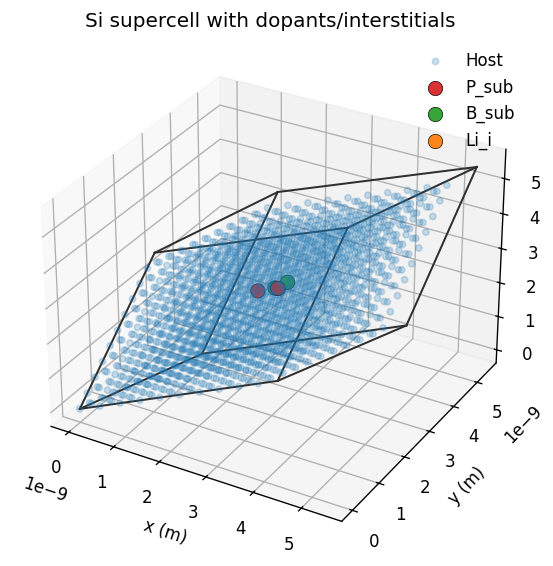

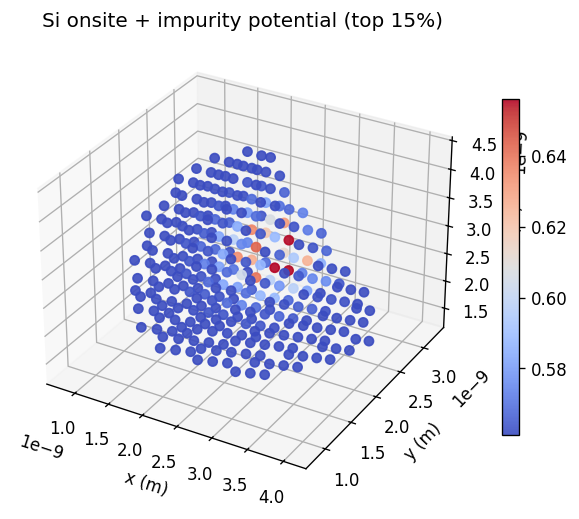

In [7]:
fig, ax = plot_supercell_structure(
    cart_positions_si,
    species_si,
    supercell_vectors_si,
    title="Si supercell with dopants/interstitials",
)
plt.show()
save_fig(fig, results_dir_si / "si_supercell_structure.png")

fig, ax = plot_spatial_scatter(
    cart_positions_si,
    onsite_array_si,
    title="Si onsite + impurity potential (top 15%)",
    cmap="coolwarm",
)
plt.show()
save_fig(fig, results_dir_si / "si_impurity_potential_top15.png")


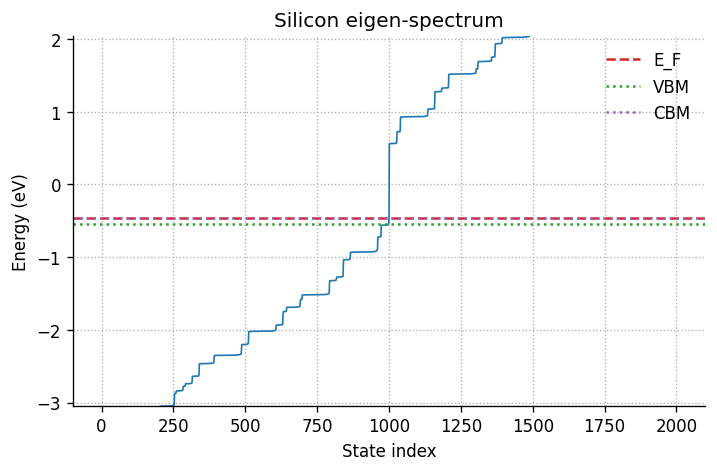

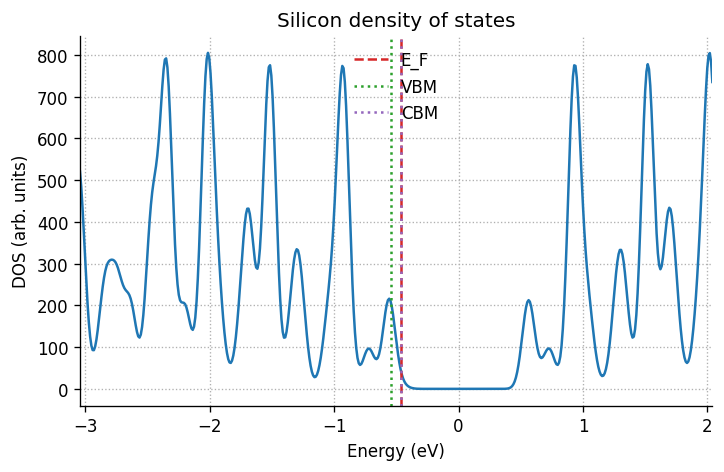

In [8]:
fig, ax = plot_spectrum(energies_si, fermi_si, vbm_si, cbm_si, "Silicon eigen-spectrum")
plt.show()
save_fig(fig, results_dir_si / "si_eigenspectrum.png")

fig, ax = plot_dos(energies_si, fermi_si, vbm_si, cbm_si, "Silicon density of states")
plt.show()
save_fig(fig, results_dir_si / "si_density_of_states.png")


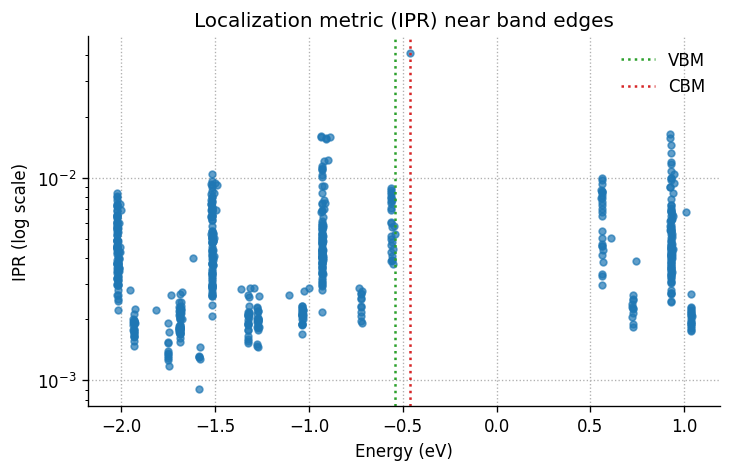

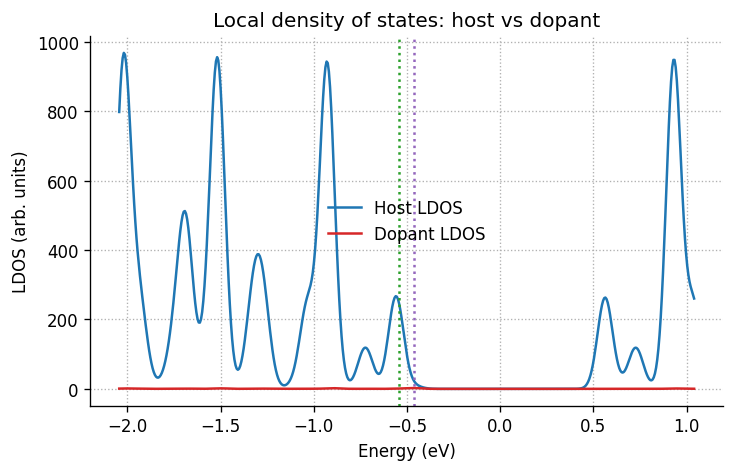

In [9]:
ipr_si = inverse_participation_ratio(states_si)

energy_window = (energies_si >= vbm_si - 1.5) & (energies_si <= cbm_si + 1.5)

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.semilogy(energies_si[energy_window], ipr_si[energy_window], "o", ms=4, color="#1f77b4", alpha=0.7)
ax.axvline(vbm_si, color="#2ca02c", linestyle=":", label="VBM")
ax.axvline(cbm_si, color="#d62728", linestyle=":", label="CBM")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("IPR (log scale)")
ax.set_title("Localization metric (IPR) near band edges")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir_si / "si_ipr_vs_energy.png")

energy_grid = np.linspace(vbm_si - 1.5, cbm_si + 1.5, 500)
ldos_dopants = local_density_of_states(
    energies_si, states_si, dopant_mask_si, energy_grid, sigma_ev=0.04
)
ldos_host = local_density_of_states(
    energies_si, states_si, ~dopant_mask_si, energy_grid, sigma_ev=0.04
)

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(energy_grid, ldos_host, color="#1f77b4", label="Host LDOS")
ax.plot(energy_grid, ldos_dopants, color="#d62728", label="Dopant LDOS")
ax.axvline(vbm_si, color="#2ca02c", linestyle=":")
ax.axvline(cbm_si, color="#9467bd", linestyle=":")
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("LDOS (arb. units)")
ax.set_title("Local density of states: host vs dopant")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir_si / "si_ldos_host_vs_dopant.png")


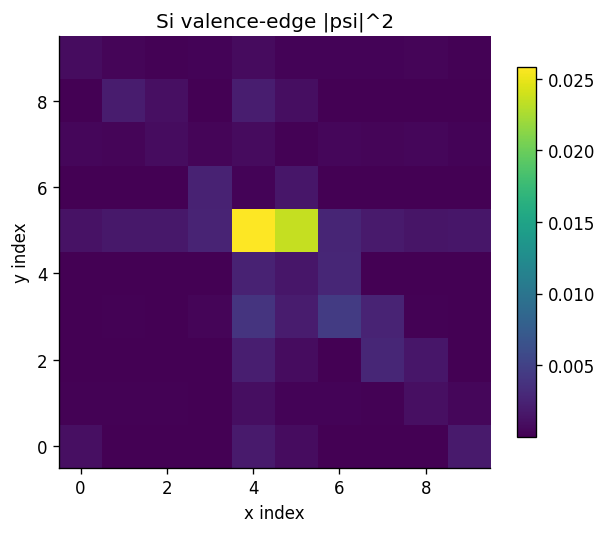

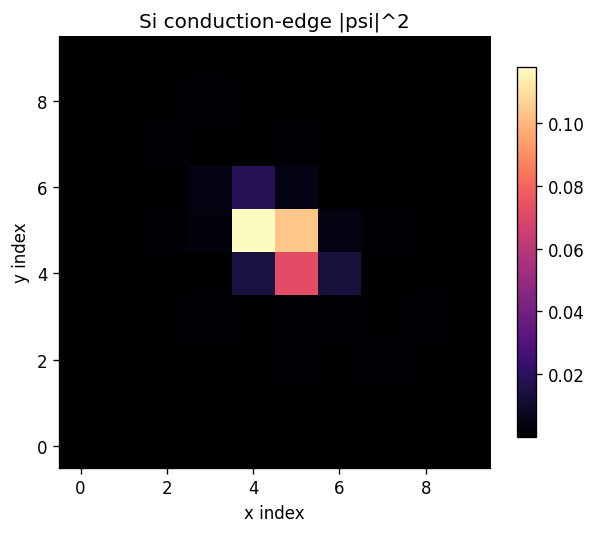

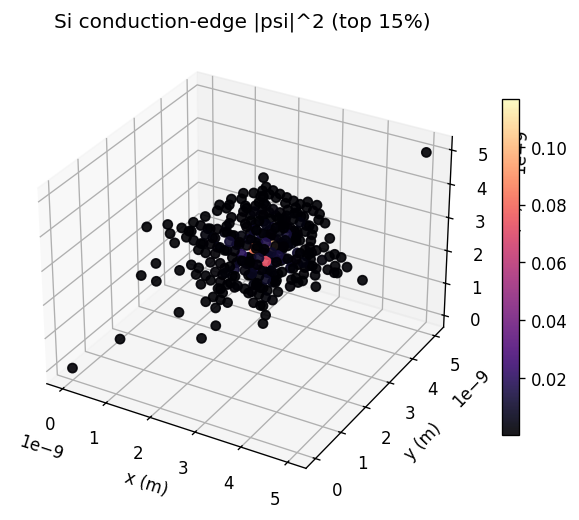

In [10]:
n_occ_si = energies_si.size // 2
valence_si = states_si[:, n_occ_si - 1]
conduction_si = states_si[:, n_occ_si]

valence_density_si = wavefunction_density_grid(valence_si, frac_positions_si, repeats_si)
conduction_density_si = wavefunction_density_grid(conduction_si, frac_positions_si, repeats_si)

slice_k = repeats_si[2] // 2
fig, ax = plot_wavefunction_slice(valence_density_si, slice_k, "Si valence-edge |psi|^2", "viridis")
plt.show()
save_fig(fig, results_dir_si / "si_valence_density_slice.png")

fig, ax = plot_wavefunction_slice(conduction_density_si, slice_k, "Si conduction-edge |psi|^2", "magma")
plt.show()
save_fig(fig, results_dir_si / "si_conduction_density_slice.png")

fig, ax = plot_spatial_scatter(
    cart_positions_si,
    np.abs(conduction_si) ** 2,
    title="Si conduction-edge |psi|^2 (top 15%)",
    cmap="magma",
    percentile=85,
)
plt.show()
save_fig(fig, results_dir_si / "si_conduction_density_top15.png")

np.savez(
    results_dir_si / "si_tb_results.npz",
    energies=energies_si,
    fermi=fermi_si,
    vbm=vbm_si,
    cbm=cbm_si,
    gap=gap_si,
    ipr=ipr_si,
    valence_state=valence_si,
    conduction_state=conduction_si,
)


In [11]:
if ANIMATION["enabled"]:
    n_occ_si = energies_si.size // 2
    n_states = int(ANIMATION["states_each_side"])
    state_indices = list(range(max(0, n_occ_si - n_states), n_occ_si + n_states))
    anim_path = results_dir_si / "si_orbital_states.html"
    save_orbital_isosurfaces_html(
        frac_positions_si,
        repeats_si,
        states_si,
        energies_si,
        state_indices,
        anim_path,
        percentile=ANIMATION["percentile"],
    )
    display(IFrame(str(anim_path), width=850, height=650))


Saved interactive orbital viewer to results_supercell_tightbinding/supercell_tightbinding_si_si_10x10x10_baseline_20261005_121309/si_orbital_states.html


## Case B: GaAs LED (zincblende structure)


In [12]:
if not ENABLE_GAAS:
    pass
else:
    fig, ax = plot_spectrum(energies_gaas, fermi_gaas, vbm_gaas, cbm_gaas, "GaAs eigen-spectrum")
    plt.show()
    save_fig(fig, results_dir_gaas / "gaas_eigenspectrum.png")

    fig, ax = plot_dos(energies_gaas, fermi_gaas, vbm_gaas, cbm_gaas, "GaAs density of states")
    plt.show()
    save_fig(fig, results_dir_gaas / "gaas_density_of_states.png")

    n_occ_gaas = energies_gaas.size // 2
    valence_gaas = states_gaas[:, n_occ_gaas - 1]
    conduction_gaas = states_gaas[:, n_occ_gaas]

    valence_density_gaas = wavefunction_density_grid(valence_gaas, frac_positions_gaas, repeats_gaas)
    conduction_density_gaas = wavefunction_density_grid(conduction_gaas, frac_positions_gaas, repeats_gaas)

    slice_k = repeats_gaas[2] // 2
    fig, ax = plot_wavefunction_slice(valence_density_gaas, slice_k, "GaAs valence-edge |psi|^2", "viridis")
    plt.show()
    save_fig(fig, results_dir_gaas / "gaas_valence_density_slice.png")

    fig, ax = plot_wavefunction_slice(conduction_density_gaas, slice_k, "GaAs conduction-edge |psi|^2", "magma")
    plt.show()
    save_fig(fig, results_dir_gaas / "gaas_conduction_density_slice.png")

    np.savez(
        results_dir_gaas / "gaas_tb_results.npz",
        energies=energies_gaas,
        fermi=fermi_gaas,
        vbm=vbm_gaas,
        cbm=cbm_gaas,
        gap=gap_gaas,
    )
